In [ ]:
# All libraries are pre-installed in Colab — just import them
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import f_oneway
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, ConfusionMatrixDisplay
)

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


In [ ]:
# Load the dataset
df = pd.read_csv('EMG-data.csv')

print('=== Dataset Shape ===')
print(f'Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}')

print('\n=== Column Names ===')
print(df.columns.tolist())

print('\n=== First 5 Rows ===')
display(df.head())

print('\n=== Class Distribution ===')
print(df['class'].value_counts().sort_index())
print('\nClass labels: 0=Unmarked, 1=Rest, 2=Fist, 3=Wrist Flex, 4=Wrist Ext, 5=Radial Dev, 6=Ulnar Dev')

=== Dataset Shape ===
Rows: 2,783,603  |  Columns: 11

=== Column Names ===
['time', 'channel1', 'channel2', 'channel3', 'channel4', 'channel5', 'channel6', 'channel7', 'channel8', 'class', 'label']

=== First 5 Rows ===


,time,channel1,channel2,channel3,channel4,channel5,channel6,channel7,channel8,class,label
0,1,0.00001,-0.00002,-0.00001,-0.00003,0.00000,-0.00001,0.00000,-0.00001,0.0,1.0
1,5,0.00001,-0.00002,-0.00001,-0.00003,0.00000,-0.00001,0.00000,-0.00001,0.0,1.0
2,6,-0.00001,0.00001,0.00002,0.00000,0.00001,-0.00002,-0.00001,0.00001,0.0,1.0
3,7,-0.00001,0.00001,0.00002,0.00000,0.00001,-0.00002,-0.00001,0.00001,0.0,1.0
4,8,-0.00001,0.00001,0.00002,0.00000,0.00001,-0.00002,-0.00001,0.00001,0.0,1.0



=== Class Distribution ===
class
0.0    1804288
1.0     161592
2.0     156820
3.0     162269
4.0     162770
5.0     163445
6.0     165313
7.0       7105
Name: count, dtype: int64

Class labels: 0=Unmarked, 1=Rest, 2=Fist, 3=Wrist Flex, 4=Wrist Ext, 5=Radial Dev, 6=Ulnar Dev


✅ Filtered dataset: 643,451 rows | Classes: [1. 2. 3. 4.]


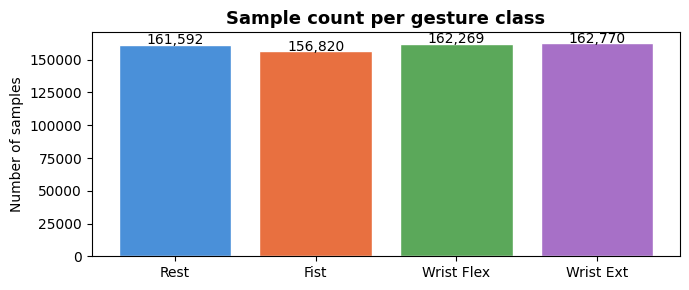

In [ ]:
# ── Filter: Keep only 4 gestures for mini project ─────────────────────────
GESTURE_IDS   = [1, 2, 3, 4]
GESTURE_NAMES = {1: 'Rest', 2: 'Fist', 3: 'Wrist Flex', 4: 'Wrist Ext'}

df = df[df['class'].isin(GESTURE_IDS)].copy()
df.reset_index(drop=True, inplace=True)

print(f'✅ Filtered dataset: {len(df):,} rows | Classes: {df["class"].unique()}')

# Plot class distribution
fig, ax = plt.subplots(figsize=(7, 3))
counts = df['class'].value_counts().sort_index()
bars = ax.bar([GESTURE_NAMES[i] for i in counts.index], counts.values,
              color=['#4A90D9','#E87040','#5BA85A','#A770C7'], edgecolor='white')
ax.set_title('Sample count per gesture class', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of samples')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:,}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

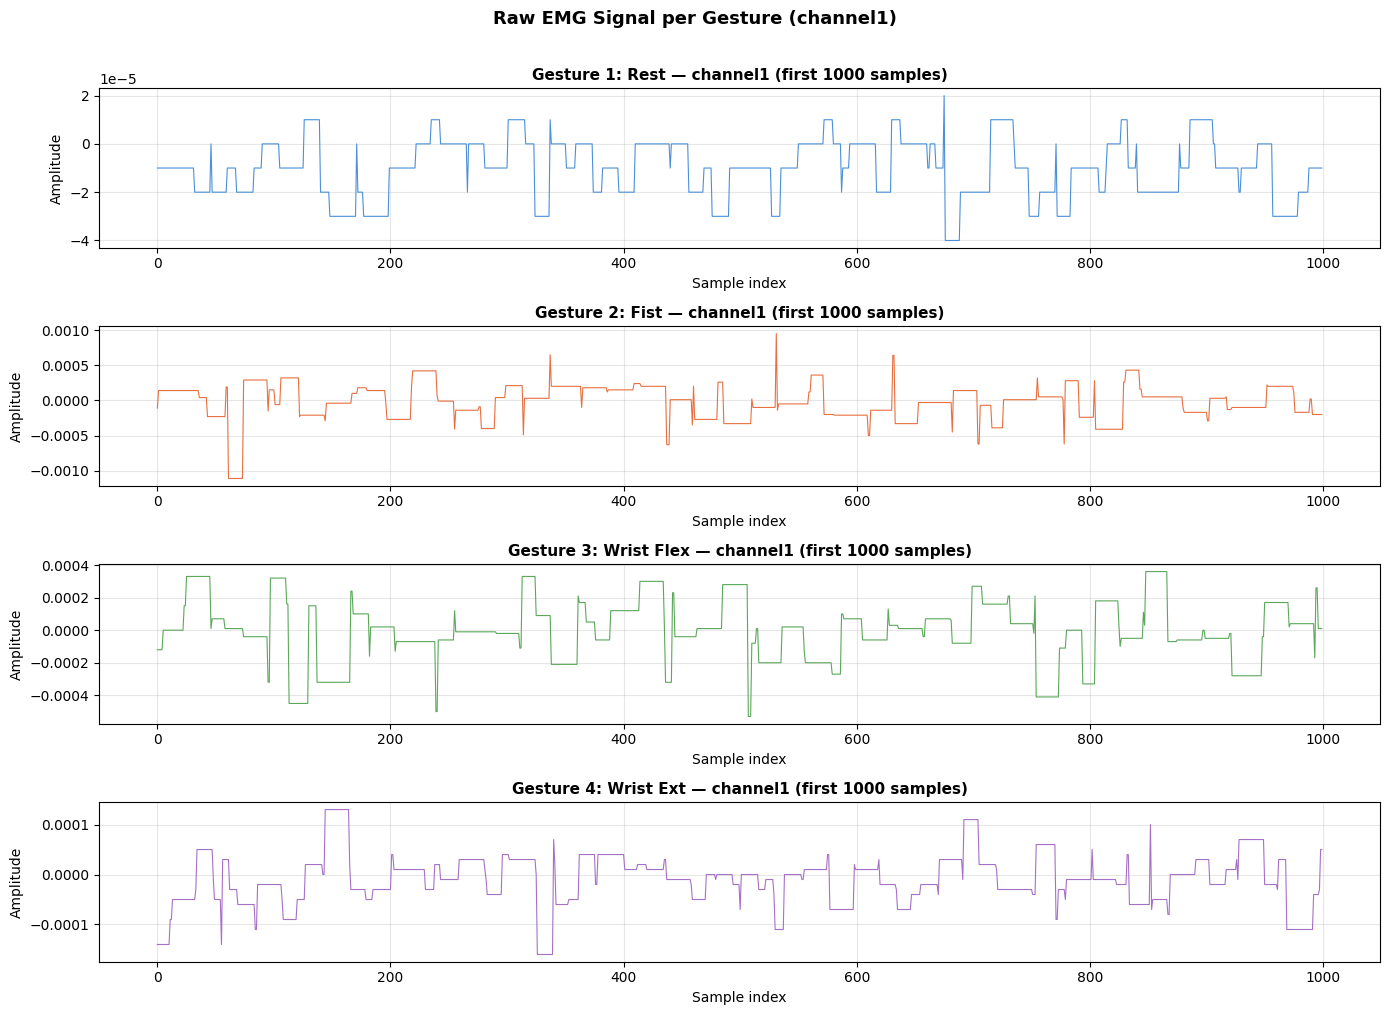

💡 Notice how signal patterns differ across gestures — this is what features capture!


In [ ]:
CHANNELS = [f'channel{i}' for i in range(1, 9)]

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=False)
colors = ['#4A90D9','#E87040','#5BA85A','#A770C7']

for idx, (gid, gname) in enumerate(GESTURE_NAMES.items()):
    segment = df[df['class'] == gid]['channel1'].values[:1000]
    axes[idx].plot(segment, color=colors[idx], linewidth=0.8)
    axes[idx].set_title(f'Gesture {gid}: {gname} — channel1 (first 1000 samples)',
                        fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Amplitude')
    axes[idx].set_xlabel('Sample index')
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Raw EMG Signal per Gesture (channel1)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print('💡 Notice how signal patterns differ across gestures — this is what features capture!')

=== ANOVA F-score per channel ===
(Higher = better class separation)

  channel1: F =       5.13  |  p = 0.001516
  channel2: F =      13.96  |  p = 0.000000
  channel3: F =       7.30  |  p = 0.000069
  channel4: F =       1.83  |  p = 0.139531
  channel5: F =     484.21  |  p = 0.000000
  channel6: F =      15.53  |  p = 0.000000
  channel7: F =      53.49  |  p = 0.000000
  channel8: F =      31.05  |  p = 0.000000

✅ Best channel selected: channel5 (F = 484.21)


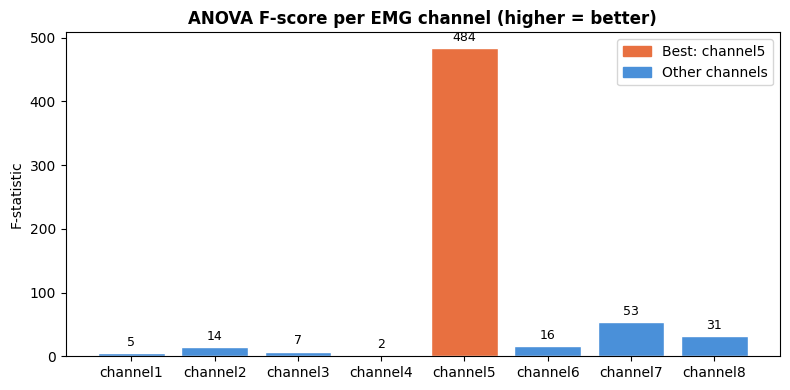

In [ ]:
print('=== ANOVA F-score per channel ===')
print('(Higher = better class separation)\n')

anova_scores = {}
for ch in CHANNELS:
    groups = [df[df['class'] == g][ch].values for g in GESTURE_IDS]
    f_stat, p_val = f_oneway(*groups)
    anova_scores[ch] = f_stat
    print(f'  {ch}: F = {f_stat:>10.2f}  |  p = {p_val:.6f}')

BEST_CHANNEL = max(anova_scores, key=anova_scores.get)
print(f'\n✅ Best channel selected: {BEST_CHANNEL} (F = {anova_scores[BEST_CHANNEL]:.2f})')

# Bar chart of F-scores
fig, ax = plt.subplots(figsize=(8, 4))
ch_names = list(anova_scores.keys())
f_vals   = list(anova_scores.values())
bar_colors = ['#E87040' if ch == BEST_CHANNEL else '#4A90D9' for ch in ch_names]
bars = ax.bar(ch_names, f_vals, color=bar_colors, edgecolor='white')
ax.set_title('ANOVA F-score per EMG channel (higher = better)', fontsize=12, fontweight='bold')
ax.set_ylabel('F-statistic')
ax.bar_label(bars, fmt='%.0f', padding=3, fontsize=9)
ax.legend(handles=[
    plt.Rectangle((0,0),1,1, color='#E87040', label=f'Best: {BEST_CHANNEL}'),
    plt.Rectangle((0,0),1,1, color='#4A90D9', label='Other channels')
])
plt.tight_layout()
plt.show()

In [ ]:
WINDOW_SIZE = 200   # samples
STEP_SIZE   = 100   # 50% overlap

def extract_features(signal_array, window=WINDOW_SIZE, step=STEP_SIZE):
    """Extract time-domain features using sliding window."""
    features = []
    for i in range(0, len(signal_array) - window, step):
        seg = signal_array[i : i + window]

        rms = np.sqrt(np.mean(seg ** 2))              # Root Mean Square
        mav = np.mean(np.abs(seg))                    # Mean Absolute Value
        zc  = np.sum(np.diff(np.sign(seg)) != 0)      # Zero Crossings
        wl  = np.sum(np.abs(np.diff(seg)))            # Waveform Length
        ssc = np.sum(np.diff(np.sign(np.diff(seg))) != 0)  # Slope Sign Changes
        var = np.var(seg)                             # Variance

        features.append([rms, mav, zc, wl, ssc, var])

    return np.array(features)


def extract_labels(label_array, window=WINDOW_SIZE, step=STEP_SIZE):
    """Extract majority class label per window."""
    labels = []
    for i in range(0, len(label_array) - window, step):
        seg = label_array[i : i + window]
        labels.append(int(pd.Series(seg).mode()[0]))
    return np.array(labels)


# Extract features from best channel
signal = df[BEST_CHANNEL].values
labels_raw = df['class'].values

X = extract_features(signal)
y = extract_labels(labels_raw)
y = y[:len(X)]  # align lengths

FEATURE_NAMES = ['RMS', 'MAV', 'ZC', 'WL', 'SSC', 'VAR']

print(f'✅ Feature matrix shape : {X.shape}  ({X.shape[0]} windows × {X.shape[1]} features)')
print(f'✅ Label array shape    : {y.shape}')
print(f'\nClass distribution after windowing:')
unique, counts = np.unique(y, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f'  {GESTURE_NAMES[cls]:15s}: {cnt} windows')


✅ Feature matrix shape : (6433, 6)  (6433 windows × 6 features)
✅ Label array shape    : (6433,)

Class distribution after windowing:
  Rest           : 1620 windows
  Fist           : 1562 windows
  Wrist Flex     : 1624 windows
  Wrist Ext      : 1627 windows


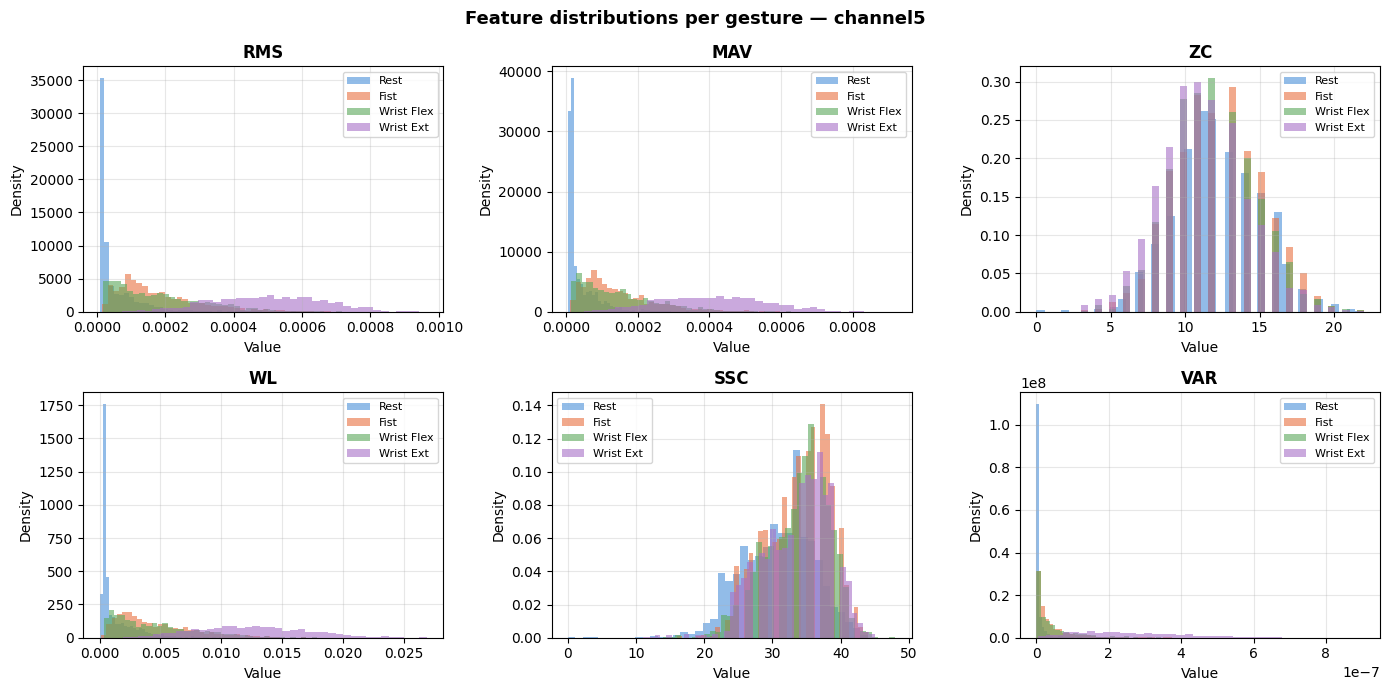

💡 Well-separated distributions = easier classification!


In [ ]:
# Visualise feature distributions per class
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
colors = ['#4A90D9','#E87040','#5BA85A','#A770C7']

for idx, feat_name in enumerate(FEATURE_NAMES):
    ax = axes[idx // 3][idx % 3]
    for gid, color in zip(GESTURE_IDS, colors):
        mask = (y == gid)
        ax.hist(X[mask, idx], bins=40, alpha=0.6,
                label=GESTURE_NAMES[gid], color=color, density=True)
    ax.set_title(feat_name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Feature distributions per gesture — {BEST_CHANNEL}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('💡 Well-separated distributions = easier classification!')

In [ ]:
# 80% train, 20% test — stratified to keep class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features (important for SVM and KNN)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Training set : {X_train.shape[0]} samples')
print(f'Test set     : {X_test.shape[0]} samples')
print(f'\n✅ StandardScaler applied (zero mean, unit variance)')

Training set : 5146 samples
Test set     : 1287 samples

✅ StandardScaler applied (zero mean, unit variance)


In [ ]:
models = {
    'Random Forest': (RandomForestClassifier(n_estimators=100, random_state=42), False),
    'SVM (RBF)':     (SVC(kernel='rbf', C=10, gamma='scale', random_state=42), True),
    'KNN (k=5)':     (KNeighborsClassifier(n_neighbors=5), True),
}

results = {}

print('=== Model Comparison ===\n')
print(f'{"Model":<20} {"Train Acc":>10} {"Test Acc":>10} {"CV Acc (5-fold)":>16}')
print('-' * 60)

for name, (clf, use_scaled) in models.items():
    Xtr = X_train_s if use_scaled else X_train
    Xte = X_test_s  if use_scaled else X_test

    clf.fit(Xtr, y_train)
    y_pred     = clf.predict(Xte)
    train_acc  = clf.score(Xtr, y_train)
    test_acc   = accuracy_score(y_test, y_pred)
    cv_scores  = cross_val_score(clf, Xtr, y_train, cv=5, scoring='accuracy')

    results[name] = {
        'clf': clf, 'pred': y_pred,
        'train_acc': train_acc, 'test_acc': test_acc,
        'cv_mean': cv_scores.mean(), 'cv_std': cv_scores.std()
    }

    print(f'{name:<20} {train_acc:>10.3f} {test_acc:>10.3f} '
          f'{cv_scores.mean():>10.3f} ± {cv_scores.std():.3f}')

# Find best model by CV score
best_model_name = max(results, key=lambda k: results[k]['cv_mean'])
print(f'\n🏆 Best model: {best_model_name} '
      f'(CV acc = {results[best_model_name]["cv_mean"]:.3f})')

=== Model Comparison ===

Model                 Train Acc   Test Acc  CV Acc (5-fold)
------------------------------------------------------------
Random Forest             1.000      0.604      0.600 ± 0.015
SVM (RBF)                 0.630      0.608      0.609 ± 0.015
KNN (k=5)                 0.701      0.531      0.571 ± 0.015

🏆 Best model: SVM (RBF) (CV acc = 0.609)


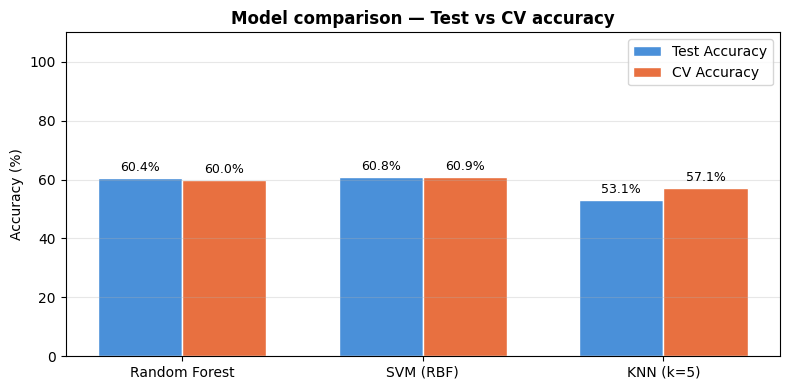

In [ ]:
# Model accuracy comparison bar chart
fig, ax = plt.subplots(figsize=(8, 4))
model_names = list(results.keys())
test_accs   = [results[m]['test_acc'] * 100 for m in model_names]
cv_accs     = [results[m]['cv_mean'] * 100  for m in model_names]

x = np.arange(len(model_names))
w = 0.35
bars1 = ax.bar(x - w/2, test_accs, w, label='Test Accuracy',  color='#4A90D9', edgecolor='white')
bars2 = ax.bar(x + w/2, cv_accs,   w, label='CV Accuracy',    color='#E87040', edgecolor='white')

ax.set_title('Model comparison — Test vs CV accuracy', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy (%)')
ax.set_xticks(x); ax.set_xticklabels(model_names)
ax.set_ylim(0, 110)
ax.bar_label(bars1, fmt='%.1f%%', padding=3, fontsize=9)
ax.bar_label(bars2, fmt='%.1f%%', padding=3, fontsize=9)
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [ ]:
best = results[best_model_name]
y_pred_best = best['pred']
gesture_labels = [GESTURE_NAMES[g] for g in GESTURE_IDS]

print(f'=== Classification Report: {best_model_name} ===\n')
print(classification_report(
    y_test, y_pred_best,
    target_names=gesture_labels
))

=== Classification Report: SVM (RBF) ===

              precision    recall  f1-score   support

        Rest       0.74      0.80      0.76       324
        Fist       0.44      0.53      0.48       312
  Wrist Flex       0.45      0.26      0.33       325
   Wrist Ext       0.74      0.84      0.79       326

    accuracy                           0.61      1287
   macro avg       0.59      0.61      0.59      1287
weighted avg       0.59      0.61      0.59      1287



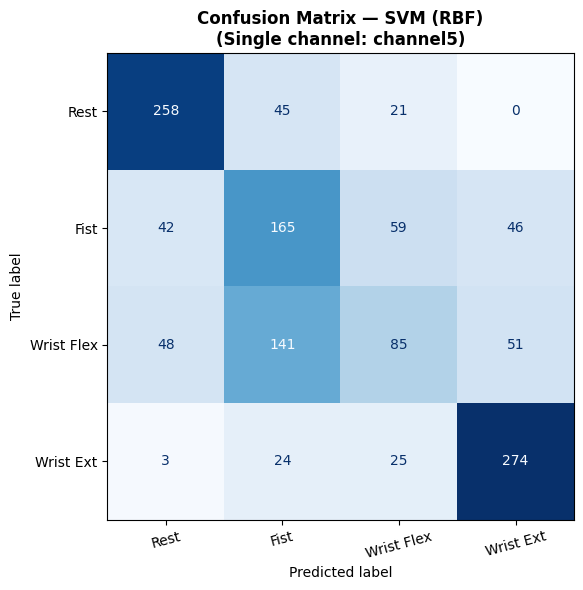

✅ Confusion matrix saved as confusion_matrix.png


In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=gesture_labels
)
disp.plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=15)
ax.set_title(f'Confusion Matrix — {best_model_name}\n(Single channel: {BEST_CHANNEL})',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Confusion matrix saved as confusion_matrix.png')

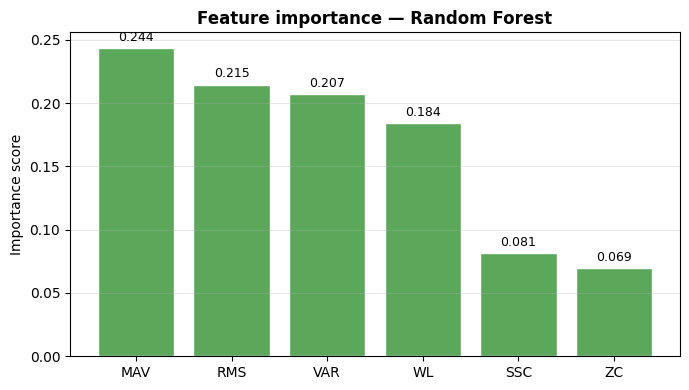

✅ Feature importance saved as feature_importance.png

💡 Most important feature: MAV


In [ ]:
# Feature importance (only for Random Forest)
if 'Random Forest' in results:
    rf_clf = results['Random Forest']['clf']
    importances = rf_clf.feature_importances_
    sorted_idx  = np.argsort(importances)[::-1]

    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(
        [FEATURE_NAMES[i] for i in sorted_idx],
        importances[sorted_idx],
        color='#5BA85A', edgecolor='white'
    )
    ax.set_title('Feature importance — Random Forest', fontsize=12, fontweight='bold')
    ax.set_ylabel('Importance score')
    ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Feature importance saved as feature_importance.png')
    print(f'\n💡 Most important feature: {FEATURE_NAMES[sorted_idx[0]]}')

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

print('=== Final Results Summary ===\n')
summary_rows = []

for name, res in results.items():
    prec = precision_score(y_test, res['pred'], average='weighted')
    rec  = recall_score(y_test, res['pred'], average='weighted')
    f1   = f1_score(y_test, res['pred'], average='weighted')
    summary_rows.append({
        'Model':       name,
        'Test Acc':    f"{res['test_acc']*100:.2f}%",
        'CV Acc':      f"{res['cv_mean']*100:.2f}% ± {res['cv_std']*100:.2f}%",
        'Precision':   f"{prec*100:.2f}%",
        'Recall':      f"{rec*100:.2f}%",
        'F1 Score':    f"{f1*100:.2f}%"
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

print(f'\n📌 Channel used      : {BEST_CHANNEL}')
print(f'📌 Window size        : {WINDOW_SIZE} samples')
print(f'📌 Step size          : {STEP_SIZE} samples (50% overlap)')
print(f'📌 Features extracted : {FEATURE_NAMES}')
print(f'📌 Gestures classified: {list(GESTURE_NAMES.values())}')
print(f'🏆 Best model         : {best_model_name}')

=== Final Results Summary ===



,Model,Test Acc,CV Acc,Precision,Recall,F1 Score
0,Random Forest,60.37%,59.97% ± 1.52%,60.16%,60.37%,60.03%
1,SVM (RBF),60.76%,60.88% ± 1.53%,59.18%,60.76%,59.14%
2,KNN (k=5),53.15%,57.07% ± 1.45%,52.62%,53.15%,52.62%



📌 Channel used      : channel5
📌 Window size        : 200 samples
📌 Step size          : 100 samples (50% overlap)
📌 Features extracted : ['RMS', 'MAV', 'ZC', 'WL', 'SSC', 'VAR']
📌 Gestures classified: ['Rest', 'Fist', 'Wrist Flex', 'Wrist Ext']
🏆 Best model         : SVM (RBF)


In [ ]:
# Save best model and scaler
best_clf = results[best_model_name]['clf']

joblib.dump(best_clf, 'emg_model.pkl')
joblib.dump(scaler,   'emg_scaler.pkl')

print('✅ Model saved  : emg_model.pkl')
print('✅ Scaler saved : emg_scaler.pkl')
print('\nDownload these files from the Colab file browser (📁 icon on the left).')

✅ Model saved  : emg_model.pkl
✅ Scaler saved : emg_scaler.pkl

Download these files from the Colab file browser (📁 icon on the left).


In [ ]:
# Load model and predict on a random test window
loaded_model  = joblib.load('emg_model.pkl')
loaded_scaler = joblib.load('emg_scaler.pkl')

# Pick a random sample from test set
idx = np.random.randint(0, len(X_test))
sample        = X_test[idx].reshape(1, -1)
sample_scaled = loaded_scaler.transform(sample)
actual_label  = y_test[idx]

# Predict
# Use scaled or unscaled depending on best model type
use_scaled_best = best_model_name != 'Random Forest'
pred_input      = sample_scaled if use_scaled_best else sample
prediction      = loaded_model.predict(pred_input)[0]

print('=== Single Sample Prediction Demo ===')
print(f'Sample features : {dict(zip(FEATURE_NAMES, sample[0].round(6)))}')
print(f'Actual gesture  : {GESTURE_NAMES[actual_label]} (class {actual_label})')
print(f'Predicted gesture: {GESTURE_NAMES[prediction]} (class {prediction})')
print(f'Result          : {"✅ CORRECT" if prediction == actual_label else "❌ WRONG"}')

=== Single Sample Prediction Demo ===
Sample features : {'RMS': np.float64(4.4e-05), 'MAV': np.float64(3.5e-05), 'ZC': np.float64(13.0), 'WL': np.float64(0.00123), 'SSC': np.float64(35.0), 'VAR': np.float64(0.0)}
Actual gesture  : Fist (class 2)
Predicted gesture: Rest (class 1)
Result          : ❌ WRONG


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from scipy.signal import butter, filtfilt
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score
)

print('✅ All libraries imported!')

✅ All libraries imported!


In [ ]:
df = pd.read_csv('my_emg_dataset.csv')

# Gesture label map (update names here if your gestures are different)
GESTURE_NAMES = {
    1: 'Rest',
    2: 'Fist',
    3: 'Wrist Flex',
    4: 'Wrist Ext'
}
GESTURE_IDS = list(GESTURE_NAMES.keys())

print('=== Dataset Overview ===')
print(f'Shape       : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Columns     : {df.columns.tolist()}')
print(f'Signal range: {df["emg_raw"].min()} – {df["emg_raw"].max()}')
print(f'Classes     : {sorted(df["class"].unique())}')
print(f'Trials      : {sorted(df["trial"].unique())}')

print('\n=== Samples per class ===')
for cid, cname in GESTURE_NAMES.items():
    n = len(df[df['class'] == cid])
    print(f'  Class {cid} — {cname:<15}: {n:,} samples')

display(df.head(8))

=== Dataset Overview ===
Shape       : 183,007 rows × 4 columns
Columns     : ['time_ms', 'emg_raw', 'class', 'trial']
Signal range: 0 – 1023
Classes     : [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Trials      : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]

=== Samples per class ===
  Class 1 — Rest           : 45,397 samples
  Class 2 — Fist           : 46,076 samples
  Class 3 — Wrist Flex     : 45,857 samples
  Class 4 — Wrist Ext      : 45,677 samples


,time_ms,emg_raw,class,trial
0,1,14,1,1
1,1,145,1,1
2,1,20,1,1
3,1,29,1,1
4,1,21,1,1
5,1,24,1,1
6,1,79,1,1
7,1,26,1,1


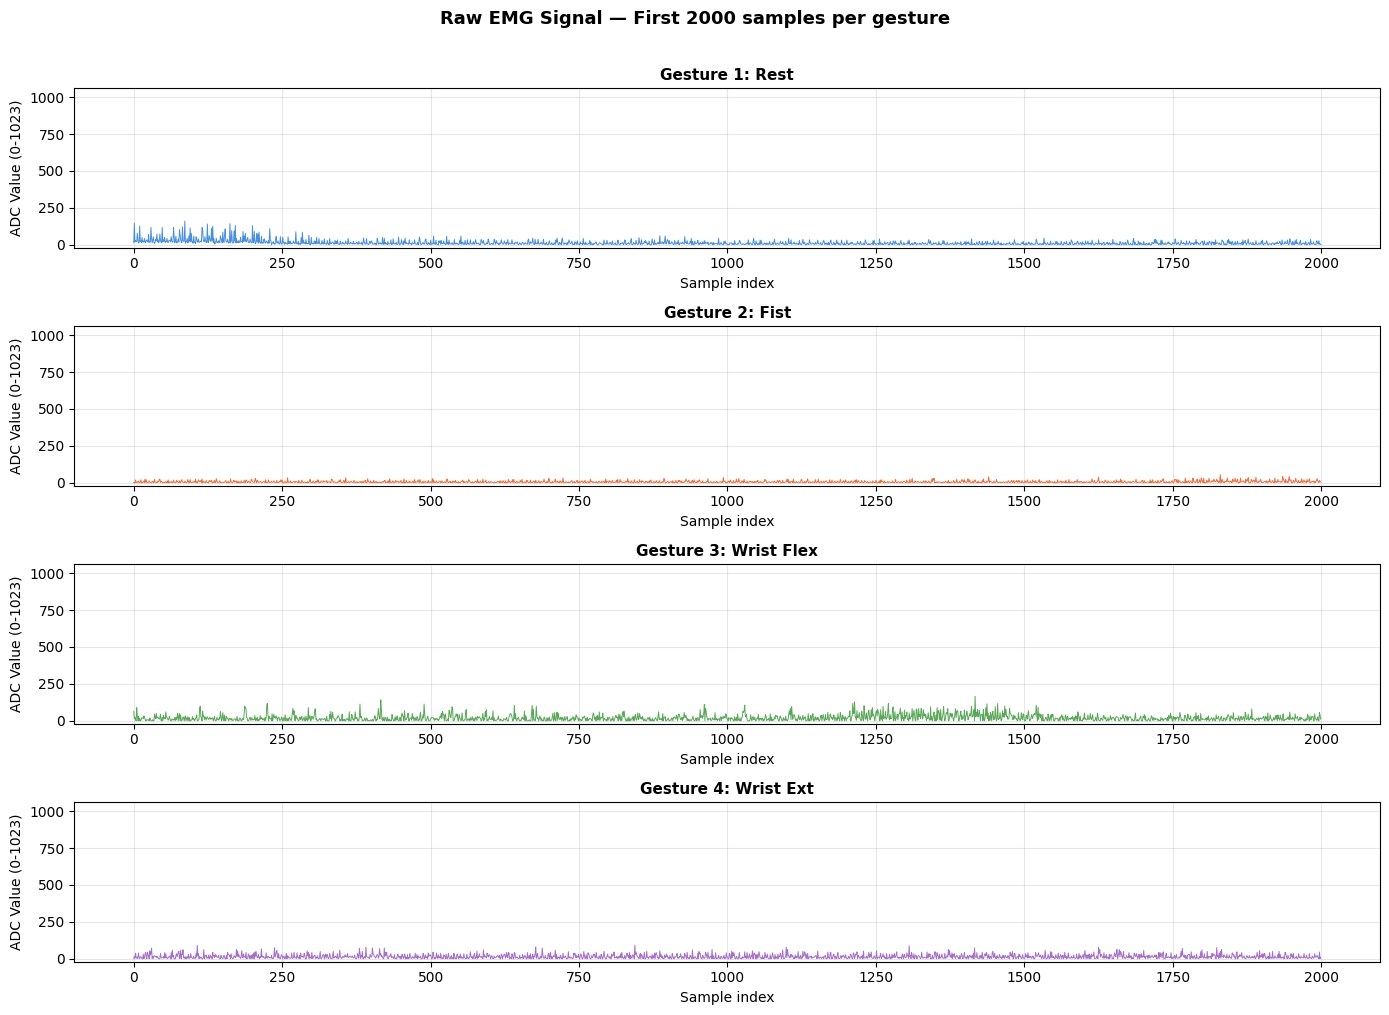

💡 Different activation patterns visible across gestures.
✅ Saved: raw_emg_signals.png


In [ ]:
COLORS = ['#4A90D9', '#E87040', '#5BA85A', '#A770C7']
N_SHOW = 2000  # samples to plot per gesture

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=False)

for idx, (gid, gname) in enumerate(GESTURE_NAMES.items()):
    seg = df[df['class'] == gid]['emg_raw'].values[:N_SHOW]
    axes[idx].plot(seg, color=COLORS[idx], linewidth=0.7)
    axes[idx].set_title(f'Gesture {gid}: {gname}', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('ADC Value (0-1023)')
    axes[idx].set_ylim(-20, 1060)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_xlabel('Sample index')

plt.suptitle('Raw EMG Signal — First 2000 samples per gesture',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('raw_emg_signals.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Different activation patterns visible across gestures.')
print('✅ Saved: raw_emg_signals.png')

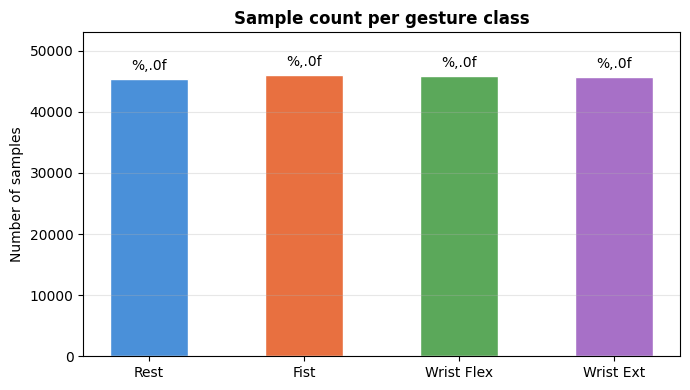

✅ Saved: class_distribution.png


In [ ]:
# Class distribution bar chart
fig, ax = plt.subplots(figsize=(7, 4))
counts = [len(df[df['class'] == g]) for g in GESTURE_IDS]
bars = ax.bar([GESTURE_NAMES[g] for g in GESTURE_IDS], counts,
              color=COLORS, edgecolor='white', width=0.5)
ax.set_title('Sample count per gesture class', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of samples')
ax.bar_label(bars, fmt='%,.0f', padding=4, fontsize=10)
ax.set_ylim(0, max(counts) * 1.15)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: class_distribution.png')


In [ ]:
SAMPLING_RATE =943 # Hz — as set in your Arduino code

def normalize_signal(signal):
    """Scale ADC 0-1023 to 0-1."""
    return signal / 1023.0

def bandpass_filter(signal, lowcut=20, highcut=400, fs=SAMPLING_RATE, order=4):
    """Butterworth bandpass filter for EMG."""
    nyq = fs / 2
    low  = lowcut  / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal)

# Apply to each gesture group separately (to avoid filtering across gesture boundaries)
processed_signals = {}
for gid in GESTURE_IDS:
    raw = df[df['class'] == gid]['emg_raw'].values.astype(float)
    norm   = normalize_signal(raw)
    filtered = bandpass_filter(norm)
    processed_signals[gid] = filtered
    print(f'  Class {gid} — {GESTURE_NAMES[gid]}: {len(filtered):,} samples processed')

print('\n✅ Normalization and bandpass filtering complete!')

  Class 1 — Rest: 45,397 samples processed
  Class 2 — Fist: 46,076 samples processed
  Class 3 — Wrist Flex: 45,857 samples processed
  Class 4 — Wrist Ext: 45,677 samples processed

✅ Normalization and bandpass filtering complete!


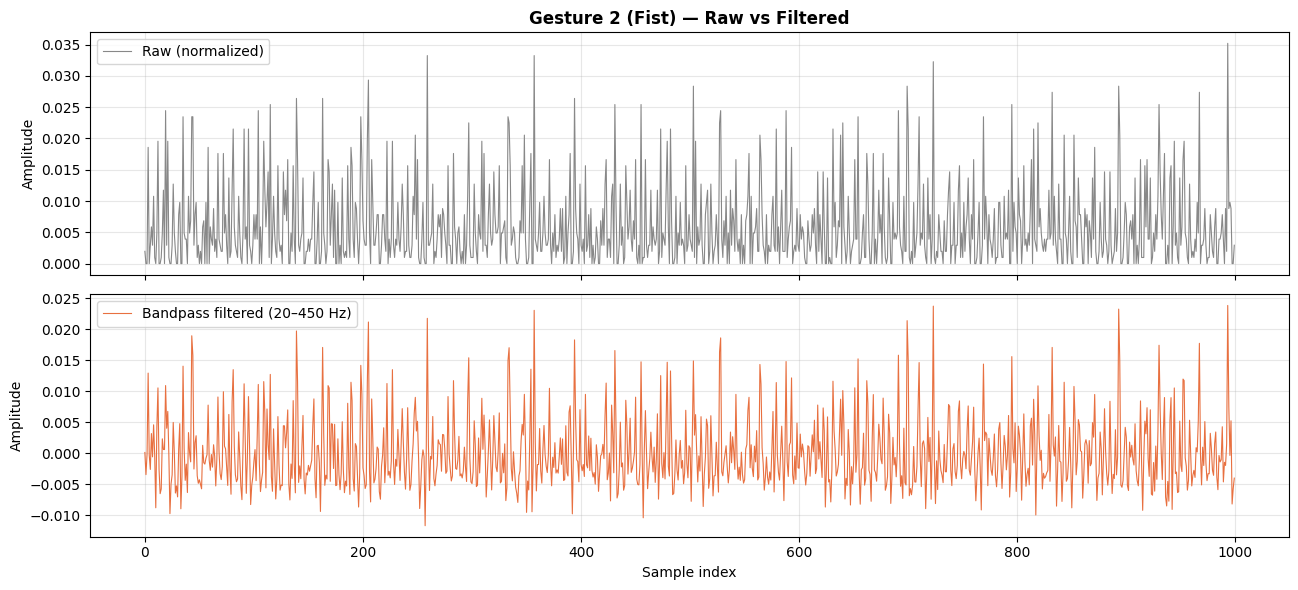

✅ Saved: raw_vs_filtered.png


In [ ]:
# Compare raw vs filtered for one gesture
gid_demo = 2  # Fist — usually most active
raw_demo = normalize_signal(df[df['class'] == gid_demo]['emg_raw'].values[:1000])
filt_demo = processed_signals[gid_demo][:1000]

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
axes[0].plot(raw_demo, color='#888', linewidth=0.8, label='Raw (normalized)')
axes[0].set_title(f'Gesture {gid_demo} ({GESTURE_NAMES[gid_demo]}) — Raw vs Filtered',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Amplitude'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(filt_demo, color='#E87040', linewidth=0.8, label='Bandpass filtered (20–450 Hz)')
axes[1].set_ylabel('Amplitude'); axes[1].set_xlabel('Sample index')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('raw_vs_filtered.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: raw_vs_filtered.png')

In [ ]:
WINDOW_SIZE = 200
STEP_SIZE   = 100
FEATURE_NAMES = ['RMS', 'MAV', 'ZC', 'WL', 'SSC', 'VAR']

def extract_features_windowed(signal, window=WINDOW_SIZE, step=STEP_SIZE):
    """Extract 6 time-domain features using sliding window."""
    features = []
    for i in range(0, len(signal) - window, step):
        seg = signal[i : i + window]
        rms = np.sqrt(np.mean(seg ** 2))
        mav = np.mean(np.abs(seg))
        zc  = int(np.sum(np.diff(np.sign(seg)) != 0))
        wl  = np.sum(np.abs(np.diff(seg)))
        ssc = int(np.sum(np.diff(np.sign(np.diff(seg))) != 0))
        var = np.var(seg)
        features.append([rms, mav, zc, wl, ssc, var])
    return np.array(features)

# Build full feature matrix and label array
X_list, y_list = [], []

for gid in GESTURE_IDS:
    sig = processed_signals[gid]
    feats = extract_features_windowed(sig)
    labels = np.full(len(feats), gid)
    X_list.append(feats)
    y_list.append(labels)
    print(f'  Class {gid} — {GESTURE_NAMES[gid]:<15}: {len(feats)} windows extracted')

X = np.vstack(X_list)
y = np.concatenate(y_list)

print(f'\n✅ Feature matrix shape : {X.shape}  ({X.shape[0]} windows × {X.shape[1]} features)')
print(f'✅ Label array shape    : {y.shape}')


  Class 1 — Rest           : 452 windows extracted
  Class 2 — Fist           : 459 windows extracted
  Class 3 — Wrist Flex     : 457 windows extracted
  Class 4 — Wrist Ext      : 455 windows extracted

✅ Feature matrix shape : (1823, 6)  (1823 windows × 6 features)
✅ Label array shape    : (1823,)


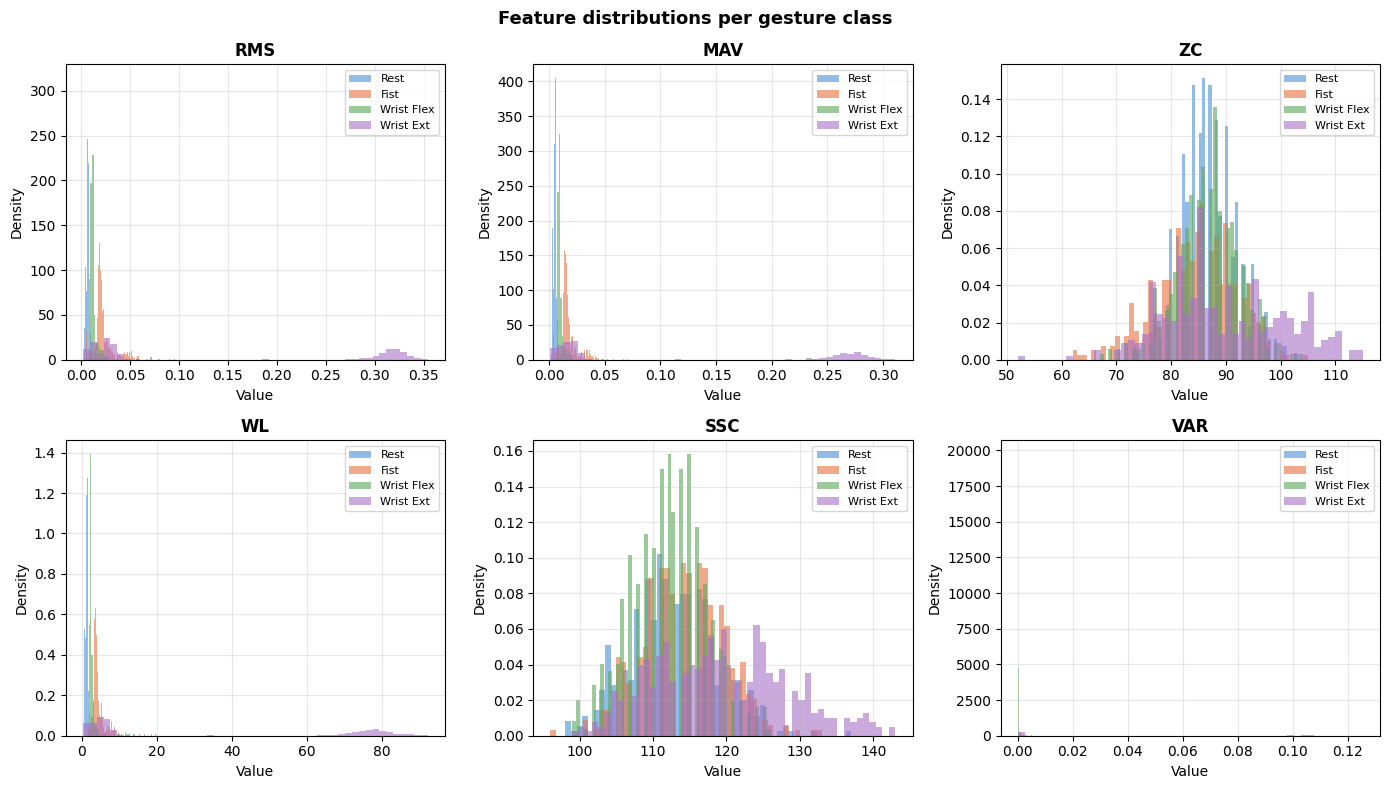

✅ Saved: feature_distributions.png
💡 Well-separated peaks = features are discriminative!


In [ ]:
# Feature distribution plots
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for idx, feat in enumerate(FEATURE_NAMES):
    ax = axes[idx // 3][idx % 3]
    for gid, color in zip(GESTURE_IDS, COLORS):
        mask = (y == gid)
        ax.hist(X[mask, idx], bins=50, alpha=0.6, density=True,
                label=GESTURE_NAMES[gid], color=color)
    ax.set_title(feat, fontsize=12, fontweight='bold')
    ax.set_xlabel('Value'); ax.set_ylabel('Density')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle('Feature distributions per gesture class',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: feature_distributions.png')
print('💡 Well-separated peaks = features are discriminative!')

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Training samples : {X_train.shape[0]:,}')
print(f'Test samples     : {X_test.shape[0]:,}')
print('\nTraining class distribution:')
for gid in GESTURE_IDS:
    n = np.sum(y_train == gid)
    print(f'  {GESTURE_NAMES[gid]:<15}: {n:,} windows')
print('\n✅ StandardScaler applied')

Training samples : 1,458
Test samples     : 365

Training class distribution:
  Rest           : 362 windows
  Fist           : 367 windows
  Wrist Flex     : 365 windows
  Wrist Ext      : 364 windows

✅ StandardScaler applied


In [ ]:
models = {
    'Random Forest': (RandomForestClassifier(n_estimators=100, random_state=42), False),
    'SVM (RBF)':     (SVC(kernel='rbf', C=10, gamma='scale', random_state=42), True),
    'KNN (k=5)':     (KNeighborsClassifier(n_neighbors=5), True),
}

results = {}
print(f'{"Model":<20} {"Train Acc":>10} {"Test Acc":>10} {"CV (5-fold)":>16}')
print('─' * 62)

for name, (clf, use_scaled) in models.items():
    Xtr = X_train_s if use_scaled else X_train
    Xte = X_test_s  if use_scaled else X_test
    clf.fit(Xtr, y_train)
    y_pred    = clf.predict(Xte)
    train_acc = clf.score(Xtr, y_train)
    test_acc  = accuracy_score(y_test, y_pred)
    cv        = cross_val_score(clf, Xtr, y_train, cv=5, scoring='accuracy')
    results[name] = {
        'clf': clf, 'pred': y_pred, 'scaled': use_scaled,
        'train_acc': train_acc, 'test_acc': test_acc,
        'cv_mean': cv.mean(), 'cv_std': cv.std()
    }
    print(f'{name:<20} {train_acc:>10.4f} {test_acc:>10.4f}  '
          f'{cv.mean():>6.4f} ± {cv.std():.4f}')

best_name = max(results, key=lambda k: results[k]['cv_mean'])
print(f'\n🏆 Best model: {best_name}  (CV = {results[best_name]["cv_mean"]:.4f})')


Model                 Train Acc   Test Acc      CV (5-fold)
──────────────────────────────────────────────────────────────
Random Forest            1.0000     0.8849  0.8697 ± 0.0148
SVM (RBF)                0.8155     0.8137  0.8031 ± 0.0161
KNN (k=5)                0.7545     0.6384  0.6200 ± 0.0296

🏆 Best model: Random Forest  (CV = 0.8697)


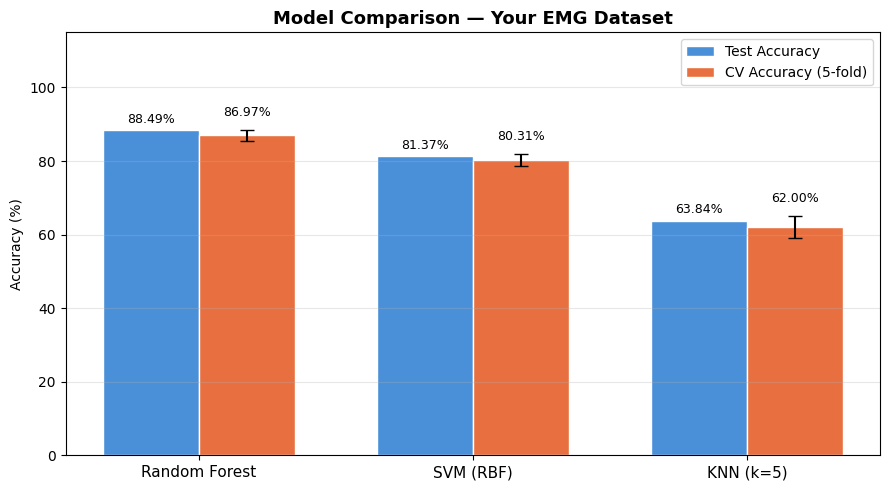

✅ Saved: model_comparison.png


In [ ]:
# Model comparison chart
fig, ax = plt.subplots(figsize=(9, 5))
model_names = list(results.keys())
test_accs = [results[m]['test_acc'] * 100 for m in model_names]
cv_accs   = [results[m]['cv_mean']  * 100 for m in model_names]
cv_stds   = [results[m]['cv_std']   * 100 for m in model_names]

x = np.arange(len(model_names))
w = 0.35
bars1 = ax.bar(x - w/2, test_accs, w, label='Test Accuracy',
               color='#4A90D9', edgecolor='white')
bars2 = ax.bar(x + w/2, cv_accs, w, label='CV Accuracy (5-fold)',
               color='#E87040', edgecolor='white',
               yerr=cv_stds, capsize=5, error_kw={'linewidth': 1.5})
ax.set_title('Model Comparison — Your EMG Dataset', fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy (%)')
ax.set_xticks(x); ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylim(0, 115)
ax.bar_label(bars1, fmt='%.2f%%', padding=3, fontsize=9)
ax.bar_label(bars2, fmt='%.2f%%', padding=8, fontsize=9)
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: model_comparison.png')

In [ ]:
best      = results[best_name]
y_pred    = best['pred']
g_labels  = [GESTURE_NAMES[g] for g in GESTURE_IDS]

print(f'=== Classification Report: {best_name} ===')
print(classification_report(y_test, y_pred, target_names=g_labels))

=== Classification Report: Random Forest ===
              precision    recall  f1-score   support

        Rest       0.96      0.94      0.95        90
        Fist       0.81      0.89      0.85        92
  Wrist Flex       0.86      0.86      0.86        92
   Wrist Ext       0.93      0.85      0.89        91

    accuracy                           0.88       365
   macro avg       0.89      0.89      0.89       365
weighted avg       0.89      0.88      0.89       365



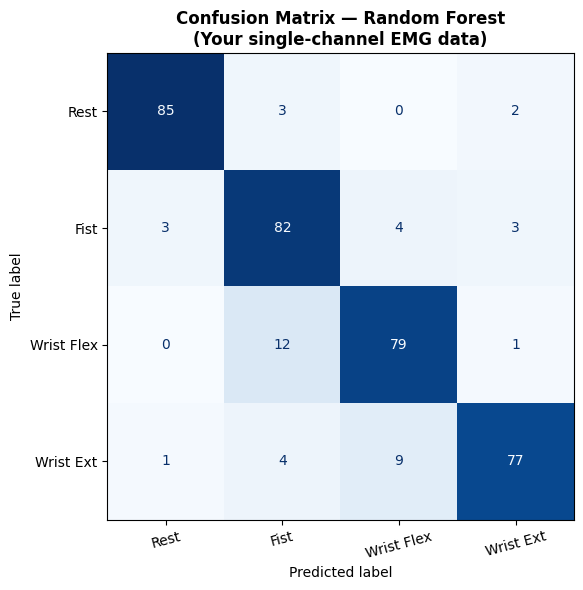

✅ Saved: confusion_matrix.png

=== Confusion Matrix Interpretation ===
  Rest           : 85/90 correct  (94.4% recall)
  Fist           : 82/92 correct  (89.1% recall)
  Wrist Flex     : 79/92 correct  (85.9% recall)
  Wrist Ext      : 77/91 correct  (84.6% recall)


In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=g_labels)
disp.plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=15)
ax.set_title(f'Confusion Matrix — {best_name}\n(Your single-channel EMG data)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: confusion_matrix.png')

# Explain the confusion matrix
print('\n=== Confusion Matrix Interpretation ===')
for i, true_name in enumerate(g_labels):
    correct   = cm[i, i]
    total_row = cm[i].sum()
    recall    = correct / total_row * 100
    print(f'  {true_name:<15}: {correct}/{total_row} correct  ({recall:.1f}% recall)')

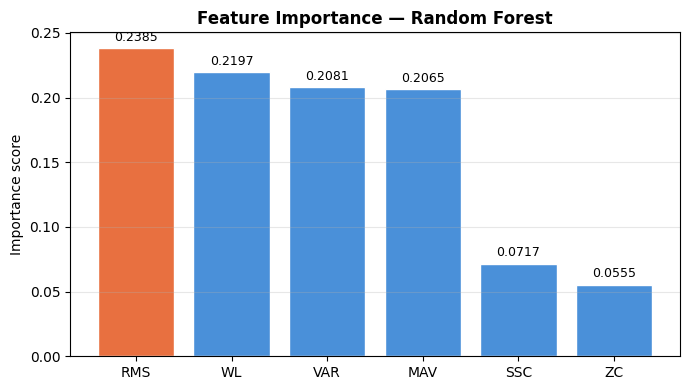

✅ Saved: feature_importance.png

💡 Most important feature: RMS
   Least important feature: ZC


In [ ]:
# Feature importance (Random Forest only)
rf_res = results.get('Random Forest')
if rf_res:
    importances = rf_res['clf'].feature_importances_
    sorted_idx  = np.argsort(importances)[::-1]

    fig, ax = plt.subplots(figsize=(7, 4))
    colors_feat = ['#E87040' if i == sorted_idx[0] else '#4A90D9' for i in range(len(FEATURE_NAMES))]
    bars = ax.bar(
        [FEATURE_NAMES[i] for i in sorted_idx],
        importances[sorted_idx],
        color=[colors_feat[i] for i in sorted_idx],
        edgecolor='white'
    )
    ax.set_title('Feature Importance — Random Forest', fontsize=12, fontweight='bold')
    ax.set_ylabel('Importance score')
    ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Saved: feature_importance.png')
    print(f'\n💡 Most important feature: {FEATURE_NAMES[sorted_idx[0]]}')
    print(f'   Least important feature: {FEATURE_NAMES[sorted_idx[-1]]}')

In [ ]:
summary_rows = []
for name, res in results.items():
    prec = precision_score(y_test, res['pred'], average='weighted')
    rec  = recall_score(y_test, res['pred'], average='weighted')
    f1   = f1_score(y_test, res['pred'], average='weighted')
    summary_rows.append({
        'Model':     name,
        'Test Acc':  f"{res['test_acc']*100:.2f}%",
        'CV Acc':    f"{res['cv_mean']*100:.2f}% ± {res['cv_std']*100:.2f}%",
        'Precision': f"{prec*100:.2f}%",
        'Recall':    f"{rec*100:.2f}%",
        'F1 Score':  f"{f1*100:.2f}%"
    })

summary_df = pd.DataFrame(summary_rows)
print('=== Final Results Summary ===')
display(summary_df)

print(f'\n📌 Dataset         : Your own single-channel EMG')
print(f'📌 Total samples   : {len(df):,}')
print(f'📌 Window size     : {WINDOW_SIZE} samples')
print(f'📌 Step size       : {STEP_SIZE} samples (50% overlap)')
print(f'📌 Features        : {FEATURE_NAMES}')
print(f'📌 Gestures        : {list(GESTURE_NAMES.values())}')
print(f'📌 Sampling rate   : {SAMPLING_RATE} Hz')
print(f'🏆 Best model      : {best_name} — {results[best_name]["test_acc"]*100:.2f}% test accuracy')

=== Final Results Summary ===


,Model,Test Acc,CV Acc,Precision,Recall,F1 Score
0,Random Forest,88.49%,86.97% ± 1.48%,88.79%,88.49%,88.55%
1,SVM (RBF),81.37%,80.31% ± 1.61%,83.02%,81.37%,81.24%
2,KNN (k=5),63.84%,62.00% ± 2.96%,64.35%,63.84%,63.80%



📌 Dataset         : Your own single-channel EMG
📌 Total samples   : 183,007
📌 Window size     : 200 samples
📌 Step size       : 100 samples (50% overlap)
📌 Features        : ['RMS', 'MAV', 'ZC', 'WL', 'SSC', 'VAR']
📌 Gestures        : ['Rest', 'Fist', 'Wrist Flex', 'Wrist Ext']
📌 Sampling rate   : 943 Hz
🏆 Best model      : Random Forest — 88.49% test accuracy


In [ ]:
print(f'=== False Positive / False Negative Analysis — {best_name} ===\n')
print(f'{"Gesture":<15} {"TP":>6} {"FP":>6} {"FN":>6} {"TN":>6} {"FPR":>8} {"FNR":>8}')
print('─' * 60)

fp_fn_rows = []
for i, (gid, gname) in enumerate(GESTURE_NAMES.items()):
    TP = cm[i, i]
    FN = cm[i].sum() - TP          # actual positives predicted as other
    FP = cm[:, i].sum() - TP       # other classes predicted as this
    TN = cm.sum() - TP - FP - FN
    FPR = FP / (FP + TN) * 100 if (FP + TN) > 0 else 0
    FNR = FN / (TP + FN) * 100 if (TP + FN) > 0 else 0
    print(f'{gname:<15} {TP:>6} {FP:>6} {FN:>6} {TN:>6} {FPR:>7.2f}% {FNR:>7.2f}%')
    fp_fn_rows.append({'Gesture': gname, 'TP': TP, 'FP': FP, 'FN': FN,
                       'TN': TN, 'FPR(%)': round(FPR,2), 'FNR(%)': round(FNR,2)})

print('\n(FPR = False Positive Rate, FNR = False Negative Rate)')
print('Lower is better for both.')

=== False Positive / False Negative Analysis — Random Forest ===

Gesture             TP     FP     FN     TN      FPR      FNR
────────────────────────────────────────────────────────────
Rest                85      4      5    271    1.45%    5.56%
Fist                82     19     10    254    6.96%   10.87%
Wrist Flex          79     13     13    260    4.76%   14.13%
Wrist Ext           77      6     14    268    2.19%   15.38%

(FPR = False Positive Rate, FNR = False Negative Rate)
Lower is better for both.


In [ ]:
best_clf = results[best_name]['clf']

joblib.dump(best_clf, 'emg_model.pkl')
joblib.dump(scaler,   'emg_scaler.pkl')

print(f'✅ Model saved  : emg_model.pkl  ({best_name})')
print('✅ Scaler saved : emg_scaler.pkl')
print('\n📥 Download from the 📁 Files panel on the left side of Colab.')
print('   These files are needed if you deploy on Raspberry Pi later.')

✅ Model saved  : emg_model.pkl  (Random Forest)
✅ Scaler saved : emg_scaler.pkl

📥 Download from the 📁 Files panel on the left side of Colab.
   These files are needed if you deploy on Raspberry Pi later.


In [ ]:
loaded_model  = joblib.load('emg_model.pkl')
loaded_scaler = joblib.load('emg_scaler.pkl')

# Pick a random test window
idx = np.random.randint(0, len(X_test))
sample = X_test[idx].reshape(1, -1)
actual = y_test[idx]

use_scaled = results[best_name]['scaled']
inp = loaded_scaler.transform(sample) if use_scaled else sample
pred = loaded_model.predict(inp)[0]

print('=== Live Prediction Demo ===')
print(f'Features   : { {f: round(v,5) for f, v in zip(FEATURE_NAMES, sample[0])} }')
print(f'Actual     : {GESTURE_NAMES[actual]} (class {actual})')
print(f'Predicted  : {GESTURE_NAMES[pred]} (class {pred})')
print(f'Result     : {"✅ CORRECT" if pred == actual else "❌ WRONG"}')

=== Live Prediction Demo ===
Features   : {'RMS': np.float64(0.02089), 'MAV': np.float64(0.01457), 'ZC': np.float64(83.0), 'WL': np.float64(4.20242), 'SSC': np.float64(116.0), 'VAR': np.float64(0.00044)}
Actual     : Wrist Ext (class 4)
Predicted  : Wrist Ext (class 4)
Result     : ✅ CORRECT


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from scipy.signal import butter, filtfilt
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score
)

print('✅ All libraries imported!')

✅ All libraries imported!


In [ ]:
df = pd.read_csv('my_emg_dataset.csv')

# Gesture label map (update names here if your gestures are different)
GESTURE_NAMES = {
    1: 'Rest',
    2: 'Fist',
}
GESTURE_IDS = list(GESTURE_NAMES.keys())

# Filter dataset to only Rest and Fist
df = df[df['class'].isin(GESTURE_IDS)].copy()
df.reset_index(drop=True, inplace=True)
print(f'Kept classes: {GESTURE_IDS} | Rows remaining: {len(df):,}')

print('=== Dataset Overview ===')
print(f'Shape       : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Columns     : {df.columns.tolist()}')
print(f'Signal range: {df["emg_raw"].min()} – {df["emg_raw"].max()}')
print(f'Classes     : {sorted(df["class"].unique())}')
print(f'Trials      : {sorted(df["trial"].unique())}')

print('\n=== Samples per class ===')
for cid, cname in GESTURE_NAMES.items():
    n = len(df[df['class'] == cid])
    print(f'  Class {cid} — {cname:<15}: {n:,} samples')

display(df.head(8))

Kept classes: [1, 2] | Rows remaining: 91,473
=== Dataset Overview ===
Shape       : 91,473 rows × 4 columns
Columns     : ['time_ms', 'emg_raw', 'class', 'trial']
Signal range: 0 – 486
Classes     : [np.int64(1), np.int64(2)]
Trials      : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]

=== Samples per class ===
  Class 1 — Rest           : 45,397 samples
  Class 2 — Fist           : 46,076 samples


,time_ms,emg_raw,class,trial
0,1,14,1,1
1,1,145,1,1
2,1,20,1,1
3,1,29,1,1
4,1,21,1,1
5,1,24,1,1
6,1,79,1,1
7,1,26,1,1


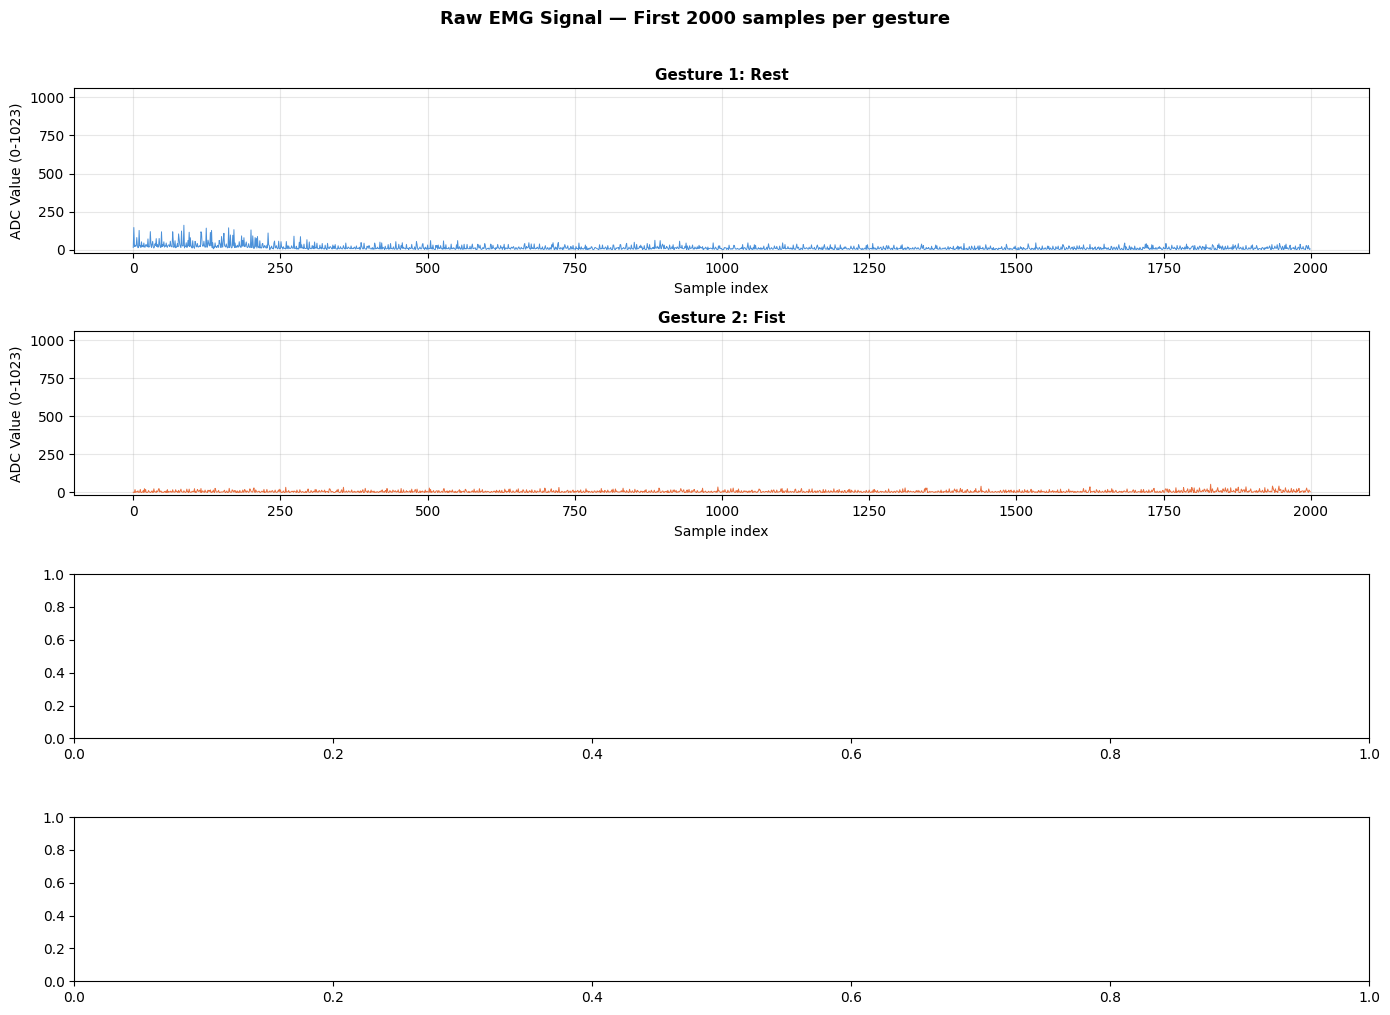

💡 Different activation patterns visible across gestures.
✅ Saved: raw_emg_signals.png


In [ ]:
COLORS = ['#4A90D9', '#E87040']
N_SHOW = 2000  # samples to plot per gesture

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=False)

for idx, (gid, gname) in enumerate(GESTURE_NAMES.items()):
    seg = df[df['class'] == gid]['emg_raw'].values[:N_SHOW]
    axes[idx].plot(seg, color=COLORS[idx], linewidth=0.7)
    axes[idx].set_title(f'Gesture {gid}: {gname}', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('ADC Value (0-1023)')
    axes[idx].set_ylim(-20, 1060)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_xlabel('Sample index')

plt.suptitle('Raw EMG Signal — First 2000 samples per gesture',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('raw_emg_signals.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Different activation patterns visible across gestures.')
print('✅ Saved: raw_emg_signals.png')

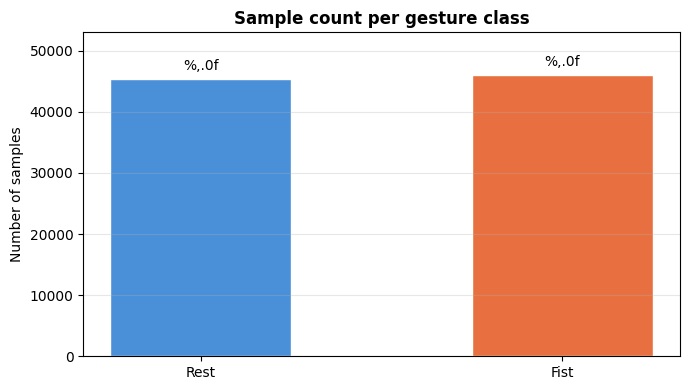

✅ Saved: class_distribution.png


In [ ]:
# Class distribution bar chart
fig, ax = plt.subplots(figsize=(7, 4))
counts = [len(df[df['class'] == g]) for g in GESTURE_IDS]
bars = ax.bar([GESTURE_NAMES[g] for g in GESTURE_IDS], counts,
              color=COLORS, edgecolor='white', width=0.5)
ax.set_title('Sample count per gesture class', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of samples')
ax.bar_label(bars, fmt='%,.0f', padding=4, fontsize=10)
ax.set_ylim(0, max(counts) * 1.15)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: class_distribution.png')

In [ ]:
SAMPLING_RATE = 943  # Hz — estimated from your time_ms column (~943 Hz actual)

def normalize_signal(signal):
    """Scale ADC 0-1023 to 0-1."""
    return signal / 1023.0

def bandpass_filter(signal, lowcut=20, highcut=400, fs=SAMPLING_RATE, order=4):
    """Butterworth bandpass filter for EMG.
    Safe cutoffs: 20–400 Hz (Nyquist at 943 Hz is ~471 Hz)
    """
    nyq = fs / 2
    low  = lowcut  / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal)

# Apply to each gesture group separately (to avoid filtering across gesture boundaries)
processed_signals = {}
for gid in GESTURE_IDS:
    raw = df[df['class'] == gid]['emg_raw'].values.astype(float)
    norm   = normalize_signal(raw)
    filtered = bandpass_filter(norm)
    processed_signals[gid] = filtered
    print(f'  Class {gid} — {GESTURE_NAMES[gid]}: {len(filtered):,} samples processed')

print('\n✅ Normalization and bandpass filtering complete!')


  Class 1 — Rest: 45,397 samples processed
  Class 2 — Fist: 46,076 samples processed

✅ Normalization and bandpass filtering complete!


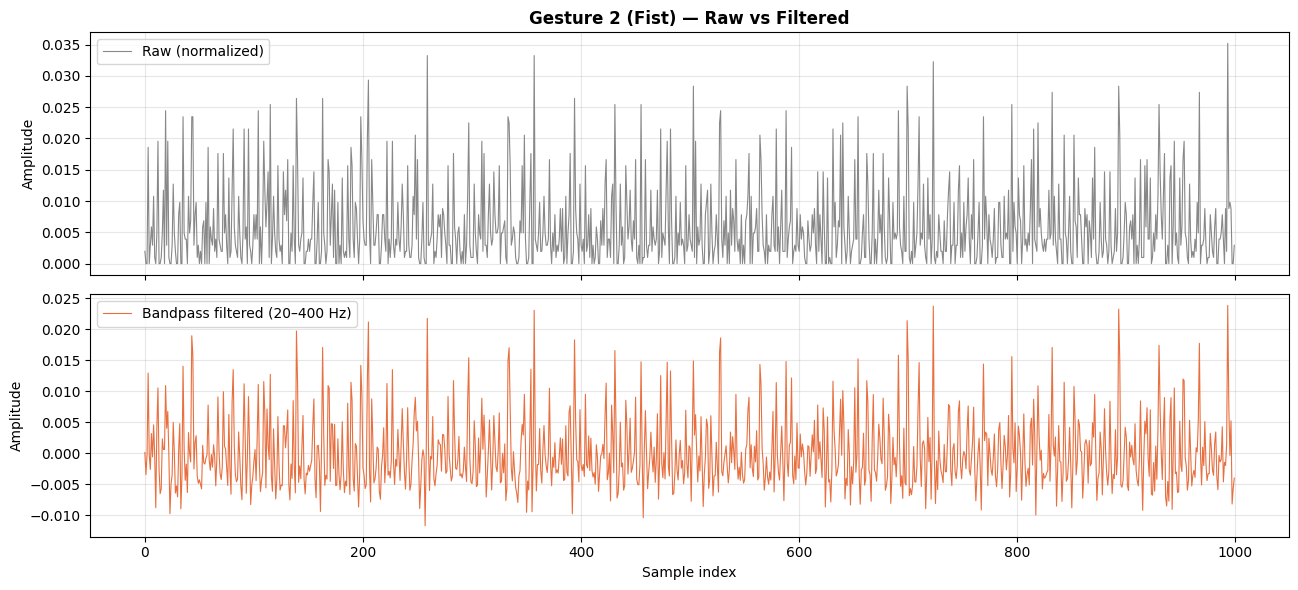

✅ Saved: raw_vs_filtered.png


In [ ]:
# Compare raw vs filtered for one gesture
gid_demo = 2  # Fist — usually most active
raw_demo = normalize_signal(df[df['class'] == gid_demo]['emg_raw'].values[:1000])
filt_demo = processed_signals[gid_demo][:1000]

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
axes[0].plot(raw_demo, color='#888', linewidth=0.8, label='Raw (normalized)')
axes[0].set_title(f'Gesture {gid_demo} ({GESTURE_NAMES[gid_demo]}) — Raw vs Filtered',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Amplitude'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(filt_demo, color='#E87040', linewidth=0.8, label='Bandpass filtered (20–400 Hz)')
axes[1].set_ylabel('Amplitude'); axes[1].set_xlabel('Sample index')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('raw_vs_filtered.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: raw_vs_filtered.png')

In [ ]:
WINDOW_SIZE = 200
STEP_SIZE   = 100
FEATURE_NAMES = ['RMS', 'MAV', 'ZC', 'WL', 'SSC', 'VAR']

def extract_features_windowed(signal, window=WINDOW_SIZE, step=STEP_SIZE):
    """Extract 6 time-domain features using sliding window."""
    features = []
    for i in range(0, len(signal) - window, step):
        seg = signal[i : i + window]
        rms = np.sqrt(np.mean(seg ** 2))
        mav = np.mean(np.abs(seg))
        zc  = int(np.sum(np.diff(np.sign(seg)) != 0))
        wl  = np.sum(np.abs(np.diff(seg)))
        ssc = int(np.sum(np.diff(np.sign(np.diff(seg))) != 0))
        var = np.var(seg)
        features.append([rms, mav, zc, wl, ssc, var])
    return np.array(features)

# Build full feature matrix and label array
X_list, y_list = [], []

for gid in GESTURE_IDS:
    sig = processed_signals[gid]
    feats = extract_features_windowed(sig)
    labels = np.full(len(feats), gid)
    X_list.append(feats)
    y_list.append(labels)
    print(f'  Class {gid} — {GESTURE_NAMES[gid]:<15}: {len(feats)} windows extracted')

X = np.vstack(X_list)
y = np.concatenate(y_list)

print(f'\n✅ Feature matrix shape : {X.shape}  ({X.shape[0]} windows × {X.shape[1]} features)')
print(f'✅ Label array shape    : {y.shape}')

  Class 1 — Rest           : 452 windows extracted
  Class 2 — Fist           : 459 windows extracted

✅ Feature matrix shape : (911, 6)  (911 windows × 6 features)
✅ Label array shape    : (911,)


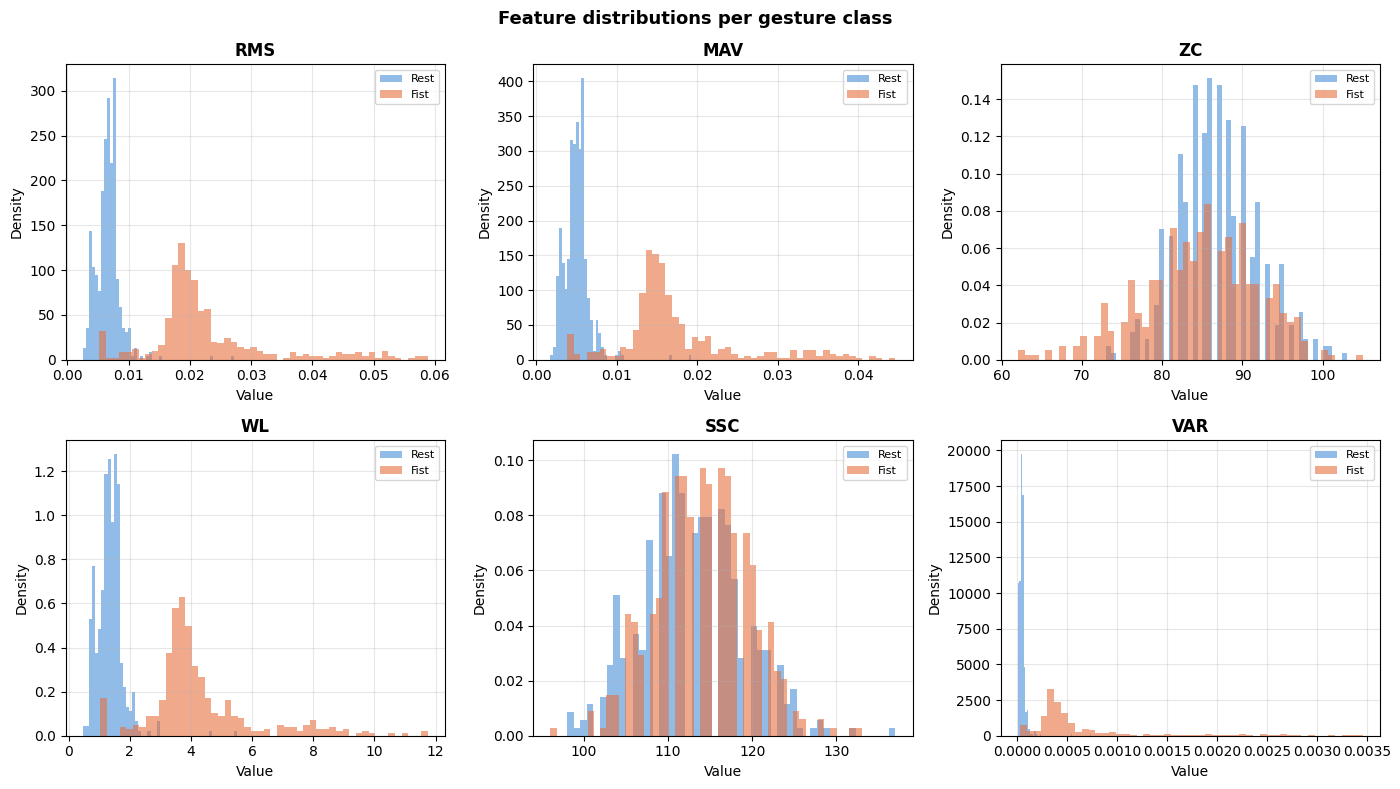

✅ Saved: feature_distributions.png
💡 Well-separated peaks = features are discriminative!


In [ ]:
# Feature distribution plots
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for idx, feat in enumerate(FEATURE_NAMES):
    ax = axes[idx // 3][idx % 3]
    for gid, color in zip(GESTURE_IDS, COLORS):
        mask = (y == gid)
        ax.hist(X[mask, idx], bins=50, alpha=0.6, density=True,
                label=GESTURE_NAMES[gid], color=color)
    ax.set_title(feat, fontsize=12, fontweight='bold')
    ax.set_xlabel('Value'); ax.set_ylabel('Density')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle('Feature distributions per gesture class',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: feature_distributions.png')
print('💡 Well-separated peaks = features are discriminative!')

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Training samples : {X_train.shape[0]:,}')
print(f'Test samples     : {X_test.shape[0]:,}')
print('\nTraining class distribution:')
for gid in GESTURE_IDS:
    n = np.sum(y_train == gid)
    print(f'  {GESTURE_NAMES[gid]:<15}: {n:,} windows')
print('\n✅ StandardScaler applied')

Training samples : 728
Test samples     : 183

Training class distribution:
  Rest           : 361 windows
  Fist           : 367 windows

✅ StandardScaler applied


In [ ]:
models = {
    'Random Forest': (RandomForestClassifier(n_estimators=100, random_state=42), False),
    'SVM (RBF)':     (SVC(kernel='rbf', C=10, gamma='scale', random_state=42), True),
    'KNN (k=5)':     (KNeighborsClassifier(n_neighbors=5), True),
}

results = {}
print(f'{"Model":<20} {"Train Acc":>10} {"Test Acc":>10} {"CV (5-fold)":>16}')
print('─' * 62)

for name, (clf, use_scaled) in models.items():
    Xtr = X_train_s if use_scaled else X_train
    Xte = X_test_s  if use_scaled else X_test
    clf.fit(Xtr, y_train)
    y_pred    = clf.predict(Xte)
    train_acc = clf.score(Xtr, y_train)
    test_acc  = accuracy_score(y_test, y_pred)
    cv        = cross_val_score(clf, Xtr, y_train, cv=5, scoring='accuracy')
    results[name] = {
        'clf': clf, 'pred': y_pred, 'scaled': use_scaled,
        'train_acc': train_acc, 'test_acc': test_acc,
        'cv_mean': cv.mean(), 'cv_std': cv.std()
    }
    print(f'{name:<20} {train_acc:>10.4f} {test_acc:>10.4f}  '
          f'{cv.mean():>6.4f} ± {cv.std():.4f}')

best_name = max(results, key=lambda k: results[k]['cv_mean'])
print(f'\n🏆 Best model: {best_name}  (CV = {results[best_name]["cv_mean"]:.4f})')

Model                 Train Acc   Test Acc      CV (5-fold)
──────────────────────────────────────────────────────────────
Random Forest            1.0000     0.9617  0.9532 ± 0.0172
SVM (RBF)                0.9588     0.9563  0.9532 ± 0.0207
KNN (k=5)                0.9547     0.9563  0.9546 ± 0.0189

🏆 Best model: KNN (k=5)  (CV = 0.9546)


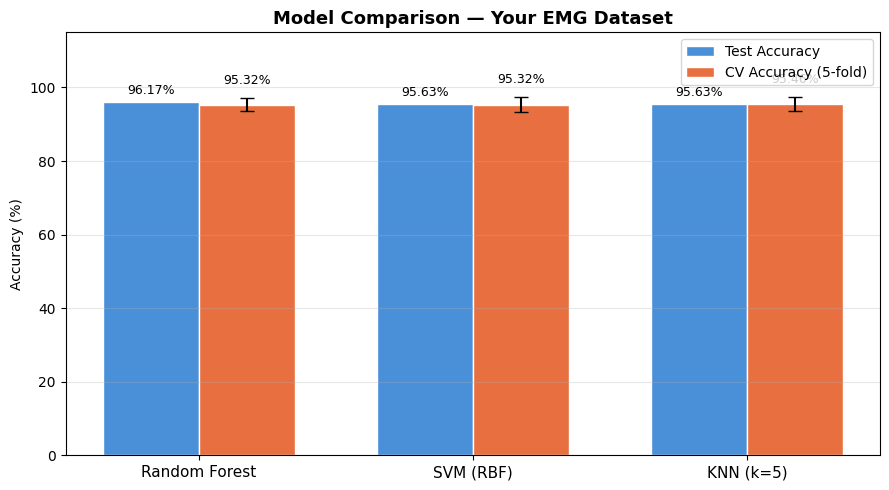

✅ Saved: model_comparison.png


In [ ]:
# Model comparison chart
fig, ax = plt.subplots(figsize=(9, 5))
model_names = list(results.keys())
test_accs = [results[m]['test_acc'] * 100 for m in model_names]
cv_accs   = [results[m]['cv_mean']  * 100 for m in model_names]
cv_stds   = [results[m]['cv_std']   * 100 for m in model_names]

x = np.arange(len(model_names))
w = 0.35
bars1 = ax.bar(x - w/2, test_accs, w, label='Test Accuracy',
               color='#4A90D9', edgecolor='white')
bars2 = ax.bar(x + w/2, cv_accs, w, label='CV Accuracy (5-fold)',
               color='#E87040', edgecolor='white',
               yerr=cv_stds, capsize=5, error_kw={'linewidth': 1.5})
ax.set_title('Model Comparison — Your EMG Dataset', fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy (%)')
ax.set_xticks(x); ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylim(0, 115)
ax.bar_label(bars1, fmt='%.2f%%', padding=3, fontsize=9)
ax.bar_label(bars2, fmt='%.2f%%', padding=8, fontsize=9)
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: model_comparison.png')

In [ ]:
best      = results[best_name]
y_pred    = best['pred']
g_labels  = [GESTURE_NAMES[g] for g in GESTURE_IDS]

print(f'=== Classification Report: {best_name} ===')
print(classification_report(y_test, y_pred, target_names=g_labels))

=== Classification Report: KNN (k=5) ===
              precision    recall  f1-score   support

        Rest       0.93      0.99      0.96        91
        Fist       0.99      0.92      0.96        92

    accuracy                           0.96       183
   macro avg       0.96      0.96      0.96       183
weighted avg       0.96      0.96      0.96       183



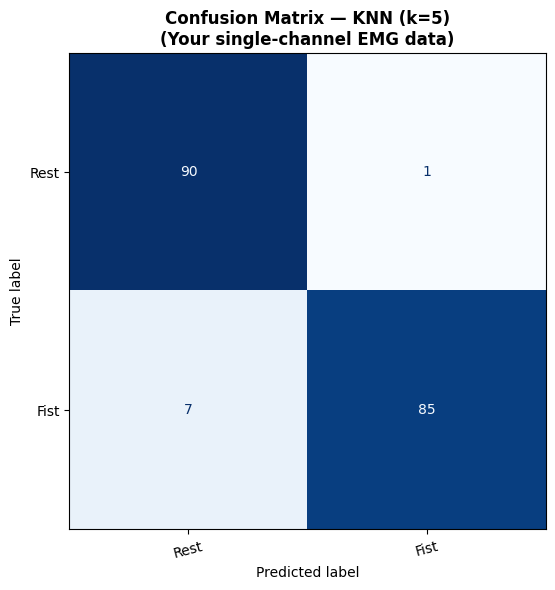

✅ Saved: confusion_matrix.png

=== Confusion Matrix Interpretation ===
  Rest           : 90/91 correct  (98.9% recall)
  Fist           : 85/92 correct  (92.4% recall)


In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=g_labels)
disp.plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=15)
ax.set_title(f'Confusion Matrix — {best_name}\n(Your single-channel EMG data)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: confusion_matrix.png')

# Explain the confusion matrix
print('\n=== Confusion Matrix Interpretation ===')
for i, true_name in enumerate(g_labels):
    correct   = cm[i, i]
    total_row = cm[i].sum()
    recall    = correct / total_row * 100
    print(f'  {true_name:<15}: {correct}/{total_row} correct  ({recall:.1f}% recall)')

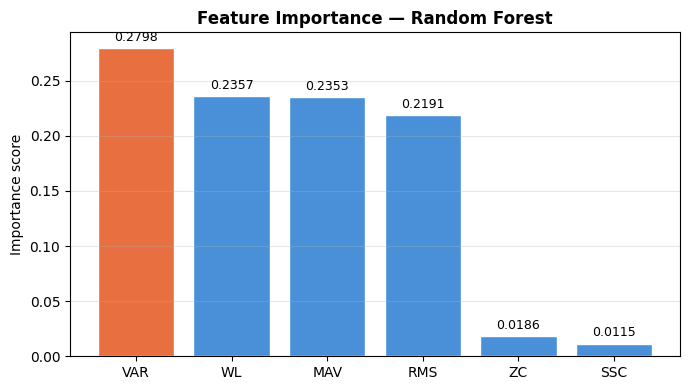

✅ Saved: feature_importance.png

💡 Most important feature: VAR
   Least important feature: SSC


In [ ]:
# Feature importance (Random Forest only)
rf_res = results.get('Random Forest')
if rf_res:
    importances = rf_res['clf'].feature_importances_
    sorted_idx  = np.argsort(importances)[::-1]

    fig, ax = plt.subplots(figsize=(7, 4))
    colors_feat = ['#E87040' if i == sorted_idx[0] else '#4A90D9' for i in range(len(FEATURE_NAMES))]
    bars = ax.bar(
        [FEATURE_NAMES[i] for i in sorted_idx],
        importances[sorted_idx],
        color=[colors_feat[i] for i in sorted_idx],
        edgecolor='white'
    )
    ax.set_title('Feature Importance — Random Forest', fontsize=12, fontweight='bold')
    ax.set_ylabel('Importance score')
    ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Saved: feature_importance.png')
    print(f'\n💡 Most important feature: {FEATURE_NAMES[sorted_idx[0]]}')
    print(f'   Least important feature: {FEATURE_NAMES[sorted_idx[-1]]}')

In [ ]:
summary_rows = []
for name, res in results.items():
    prec = precision_score(y_test, res['pred'], average='weighted')
    rec  = recall_score(y_test, res['pred'], average='weighted')
    f1   = f1_score(y_test, res['pred'], average='weighted')
    summary_rows.append({
        'Model':     name,
        'Test Acc':  f"{res['test_acc']*100:.2f}%",
        'CV Acc':    f"{res['cv_mean']*100:.2f}% ± {res['cv_std']*100:.2f}%",
        'Precision': f"{prec*100:.2f}%",
        'Recall':    f"{rec*100:.2f}%",
        'F1 Score':  f"{f1*100:.2f}%"
    })

summary_df = pd.DataFrame(summary_rows)
print('=== Final Results Summary ===')
display(summary_df)

print(f'\n📌 Dataset         : Your own single-channel EMG')
print(f'📌 Total samples   : {len(df):,}')
print(f'📌 Window size     : {WINDOW_SIZE} samples')
print(f'📌 Step size       : {STEP_SIZE} samples (50% overlap)')
print(f'📌 Features        : {FEATURE_NAMES}')
print(f'📌 Gestures        : {list(GESTURE_NAMES.values())}')
print(f'📌 Sampling rate   : {SAMPLING_RATE} Hz')
print(f'🏆 Best model      : {best_name} — {results[best_name]["test_acc"]*100:.2f}% test accuracy')

=== Final Results Summary ===


,Model,Test Acc,CV Acc,Precision,Recall,F1 Score
0,Random Forest,96.17%,95.32% ± 1.72%,96.18%,96.17%,96.17%
1,SVM (RBF),95.63%,95.32% ± 2.07%,95.83%,95.63%,95.62%
2,KNN (k=5),95.63%,95.46% ± 1.89%,95.83%,95.63%,95.62%



📌 Dataset         : Your own single-channel EMG
📌 Total samples   : 91,473
📌 Window size     : 200 samples
📌 Step size       : 100 samples (50% overlap)
📌 Features        : ['RMS', 'MAV', 'ZC', 'WL', 'SSC', 'VAR']
📌 Gestures        : ['Rest', 'Fist']
📌 Sampling rate   : 943 Hz
🏆 Best model      : KNN (k=5) — 95.63% test accuracy


In [ ]:
print(f'=== False Positive / False Negative Analysis — {best_name} ===\n')
print(f'{"Gesture":<15} {"TP":>6} {"FP":>6} {"FN":>6} {"TN":>6} {"FPR":>8} {"FNR":>8}')
print('─' * 60)

fp_fn_rows = []
for i, (gid, gname) in enumerate(GESTURE_NAMES.items()):
    TP = cm[i, i]
    FN = cm[i].sum() - TP          # actual positives predicted as other
    FP = cm[:, i].sum() - TP       # other classes predicted as this
    TN = cm.sum() - TP - FP - FN
    FPR = FP / (FP + TN) * 100 if (FP + TN) > 0 else 0
    FNR = FN / (TP + FN) * 100 if (TP + FN) > 0 else 0
    print(f'{gname:<15} {TP:>6} {FP:>6} {FN:>6} {TN:>6} {FPR:>7.2f}% {FNR:>7.2f}%')
    fp_fn_rows.append({'Gesture': gname, 'TP': TP, 'FP': FP, 'FN': FN,
                       'TN': TN, 'FPR(%)': round(FPR,2), 'FNR(%)': round(FNR,2)})

print('\n(FPR = False Positive Rate, FNR = False Negative Rate)')
print('Lower is better for both.')

=== False Positive / False Negative Analysis — KNN (k=5) ===

Gesture             TP     FP     FN     TN      FPR      FNR
────────────────────────────────────────────────────────────
Rest                90      7      1     85    7.61%    1.10%
Fist                85      1      7     90    1.10%    7.61%

(FPR = False Positive Rate, FNR = False Negative Rate)
Lower is better for both.


In [ ]:
best_clf = results[best_name]['clf']

joblib.dump(best_clf, 'emg_model.pkl')
joblib.dump(scaler,   'emg_scaler.pkl')

print(f'✅ Model saved  : emg_model.pkl  ({best_name})')
print('✅ Scaler saved : emg_scaler.pkl')
print('\n📥 Download from the 📁 Files panel on the left side of Colab.')
print('   These files are needed if you deploy on Raspberry Pi later.')

✅ Model saved  : emg_model.pkl  (KNN (k=5))
✅ Scaler saved : emg_scaler.pkl

📥 Download from the 📁 Files panel on the left side of Colab.
   These files are needed if you deploy on Raspberry Pi later.


In [ ]:
loaded_model  = joblib.load('emg_model.pkl')
loaded_scaler = joblib.load('emg_scaler.pkl')

# Pick a random test window
idx = np.random.randint(0, len(X_test))
sample = X_test[idx].reshape(1, -1)
actual = y_test[idx]

use_scaled = results[best_name]['scaled']
inp = loaded_scaler.transform(sample) if use_scaled else sample
pred = loaded_model.predict(inp)[0]

print('=== Live Prediction Demo ===')
print(f'Features   : { {f: round(v,5) for f, v in zip(FEATURE_NAMES, sample[0])} }')
print(f'Actual     : {GESTURE_NAMES[actual]} (class {actual})')
print(f'Predicted  : {GESTURE_NAMES[pred]} (class {pred})')
print(f'Result     : {"✅ CORRECT" if pred == actual else "❌ WRONG"}')

=== Live Prediction Demo ===
Features   : {'RMS': np.float64(0.02116), 'MAV': np.float64(0.01686), 'ZC': np.float64(82.0), 'WL': np.float64(4.00023), 'SSC': np.float64(120.0), 'VAR': np.float64(0.00045)}
Actual     : Fist (class 2)
Predicted  : Fist (class 2)
Result     : ✅ CORRECT
